# Setup & Requirements

In [30]:
import os

# ── Paths ──────────────────────────────────────────────────────────────────
# Folder containing your Sensor Logger export (the one with Accelerometer.csv etc.)
RECORDING_DIR = r"./data/sensor/default"

# Path to MobilePoser weights file
WEIGHTS_FILE = r"C:\Users\m_\Desktop\Poser\MobilePoser-main\weights.pth"


# Path to MobilePoser repo root (so we can import mobileposer)
MOBILEPOSER_ROOT = r"C:\Users\m_\Desktop\Poser\MobilePoser-main"

# ── Recording mode ─────────────────────────────────────────────────────────
# 'default'    → Android OS fusion (Sensor Logger without Sensor Zoo)
# 'sensor_zoo' → Madgwick filter (Sensor Logger with Sensor Zoo enabled)
RECORDING_MODE = 'default'   # change to 'sensor_zoo' if you used Sensor Zoo

# ── Synthetic fallback ─────────────────────────────────────────────────────
# Set to True to skip loading CSVs and use a synthetic walking signal instead.
# Useful for testing the pipeline before you have real recordings.
USE_SYNTHETIC = False

# ── Target sample rate ─────────────────────────────────────────────────────
# MobilePoser was trained at 30 FPS (see mobileposer/config.py → datasets.fps = 30)
TARGET_HZ = 30

print("Configuration loaded.")
print(f"  Recording dir : {RECORDING_DIR}")
print(f"  Mode          : {RECORDING_MODE}")
print(f"  Synthetic     : {USE_SYNTHETIC}")
print(f"  Target Hz     : {TARGET_HZ}")

Configuration loaded.
  Recording dir : ./data/sensor/default
  Mode          : default
  Synthetic     : False
  Target Hz     : 30


## 1. Imports

In [31]:
import sys
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R
from scipy.interpolate import interp1d
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib as mpl

mpl.rcParams['figure.figsize'] = (12, 4)
mpl.rcParams['animation.embed_limit'] = 120.0   # MB — prevents size-limit errors

# Add MobilePoser to path so we can import its modules
if MOBILEPOSER_ROOT not in sys.path:
    sys.path.insert(0, MOBILEPOSER_ROOT)

print("Imports OK")

Imports OK


## 2. Load Sensor Logger CSVs

Sensor Logger exports one CSV per sensor. We need four files:

| File | What it contains |
|------|------------------|
| `TotalAcceleration.csv` | Phone linear accel **including** gravity (what MobilePoser expects) |
| `Orientation.csv` | Phone orientation as quaternion + Euler |
| `WatchAccelerometer.csv` | Watch linear accel |
| `WatchOrientation.csv` | Watch orientation |

> **Why TotalAcceleration and not Accelerometer?**  
> The regular `Accelerometer.csv` has gravity removed by the Android OS.  
> MobilePoser was trained on raw IMU data that **includes** gravity, matching `TotalAcceleration`.

In [32]:
def load_csv(folder, filename):
    """Load a Sensor Logger CSV and return a DataFrame."""
    path = os.path.join(folder, filename)
    if not os.path.exists(path):
        raise FileNotFoundError(f"Expected file not found: {path}")
    df = pd.read_csv(path)
    print(f"  {filename}: {len(df)} rows, columns = {list(df.columns)}")
    return df


if USE_SYNTHETIC:
    print("[Synthetic mode] Skipping CSV loading.")
    phone_acc_df = phone_ori_df = watch_acc_df = watch_ori_df = None
else:
    print("Loading CSVs...")
    phone_acc_df  = load_csv(RECORDING_DIR, "TotalAcceleration.csv")
    phone_ori_df  = load_csv(RECORDING_DIR, "Orientation.csv")
    watch_acc_df  = load_csv(RECORDING_DIR, "WatchAccelerometer.csv")
    watch_ori_df  = load_csv(RECORDING_DIR, "WatchOrientation.csv")
    print("Done.")

Loading CSVs...
  TotalAcceleration.csv: 2254 rows, columns = ['time', 'seconds_elapsed', 'z', 'y', 'x']
  Orientation.csv: 2187 rows, columns = ['time', 'seconds_elapsed', 'qz', 'qy', 'qx', 'qw', 'roll', 'pitch', 'yaw']
  WatchAccelerometer.csv: 2913 rows, columns = ['time', 'seconds_elapsed', 'z', 'y', 'x']
  WatchOrientation.csv: 2858 rows, columns = ['time', 'seconds_elapsed', 'yaw', 'pitch', 'qy', 'qz', 'roll', 'qx', 'qw']
Done.


## 3. Column Normalisation

Sensor Logger uses different column names depending on whether you record in Default mode or with Sensor Zoo (Madgwick filter).  
This cell unifies them so the rest of the notebook works identically for both modes.

| Field | Default columns | Sensor Zoo columns |
|-------|----------------|--------------------|
| Accel axes | `z, y, x` order | `x, y, z` order |
| Quaternion | `qz, qy, qx, qw` | `qw, qx, qy, qz` |
| Timestamp | `time` (epoch ns) | `time` (epoch ns) |

In [33]:
def extract_time_seconds(df):
    """
    Returns a numpy array of timestamps in seconds.
    Sensor Logger timestamps are epoch nanoseconds in the 'time' column.
    We convert to relative seconds from the first sample.
    """
    t_ns = df['time'].values.astype(np.float64)
    return (t_ns - t_ns[0]) * 1e-9


def extract_acceleration(df, mode):
    """
    Returns (timestamps_s, acc_xyz) where acc_xyz has shape (N, 3).
    Handles column order differences between Default and Sensor Zoo.
    """
    t = extract_time_seconds(df)

    if mode == 'sensor_zoo':
        # Sensor Zoo: columns are x, y, z in that order
        acc = df[['x', 'y', 'z']].values.astype(np.float32)
    else:
        # Default Android OS: columns may be z, y, x — always select by name
        if 'x' in df.columns:
            acc = df[['x', 'y', 'z']].values.astype(np.float32)
        else:
            # Fallback: try positional (risky — use for diagnostics only)
            print("  WARNING: no x/y/z columns found. Using columns:", list(df.columns))
            acc = df.iloc[:, 1:4].values.astype(np.float32)

    return t, acc


def extract_quaternion(df, mode):
    """
    Returns (timestamps_s, quats) where quats has shape (N, 4) in [qw, qx, qy, qz] order.
    """
    t = extract_time_seconds(df)

    if mode == 'sensor_zoo':
        # Sensor Zoo: already [qw, qx, qy, qz]
        quats = df[['qw', 'qx', 'qy', 'qz']].values.astype(np.float64)
    else:
        # Default Android: [qz, qy, qx, qw] → reorder to [qw, qx, qy, qz]
        if 'qw' in df.columns:
            quats = df[['qw', 'qx', 'qy', 'qz']].values.astype(np.float64)
        elif 'qz' in df.columns:
            quats = df[['qw', 'qx', 'qy', 'qz']].values.astype(np.float64)
        else:
            print("  WARNING: quaternion columns not found. Columns:", list(df.columns))
            quats = df.iloc[:, 1:5].values.astype(np.float64)

    return t, quats


if not USE_SYNTHETIC:
    t_phone_acc,  phone_acc  = extract_acceleration(phone_acc_df,  RECORDING_MODE)
    t_watch_acc,  watch_acc  = extract_acceleration(watch_acc_df,  RECORDING_MODE)
    t_phone_ori,  phone_quat = extract_quaternion  (phone_ori_df,  RECORDING_MODE)
    t_watch_ori,  watch_quat = extract_quaternion  (watch_ori_df,  RECORDING_MODE)

    print(f"Phone acc  : {phone_acc.shape}, time range [{t_phone_acc[0]:.2f}, {t_phone_acc[-1]:.2f}] s")
    print(f"Watch acc  : {watch_acc.shape}, time range [{t_watch_acc[0]:.2f}, {t_watch_acc[-1]:.2f}] s")
    print(f"Phone ori  : {phone_quat.shape}, time range [{t_phone_ori[0]:.2f}, {t_phone_ori[-1]:.2f}] s")
    print(f"Watch ori  : {watch_quat.shape}, time range [{t_watch_ori[0]:.2f}, {t_watch_ori[-1]:.2f}] s")
else:
    print("[Synthetic mode] No CSVs to parse.")

Phone acc  : (2254, 3), time range [0.00, 41.84] s
Watch acc  : (2913, 3), time range [0.00, 40.01] s
Phone ori  : (2187, 4), time range [0.00, 41.85] s
Watch ori  : (2858, 4), time range [0.00, 40.01] s


## 4. Quick Signal Check — Plot Raw Signals

Sanity check: do the acceleration signals look like motion?
You should see rhythmic spikes during walking.

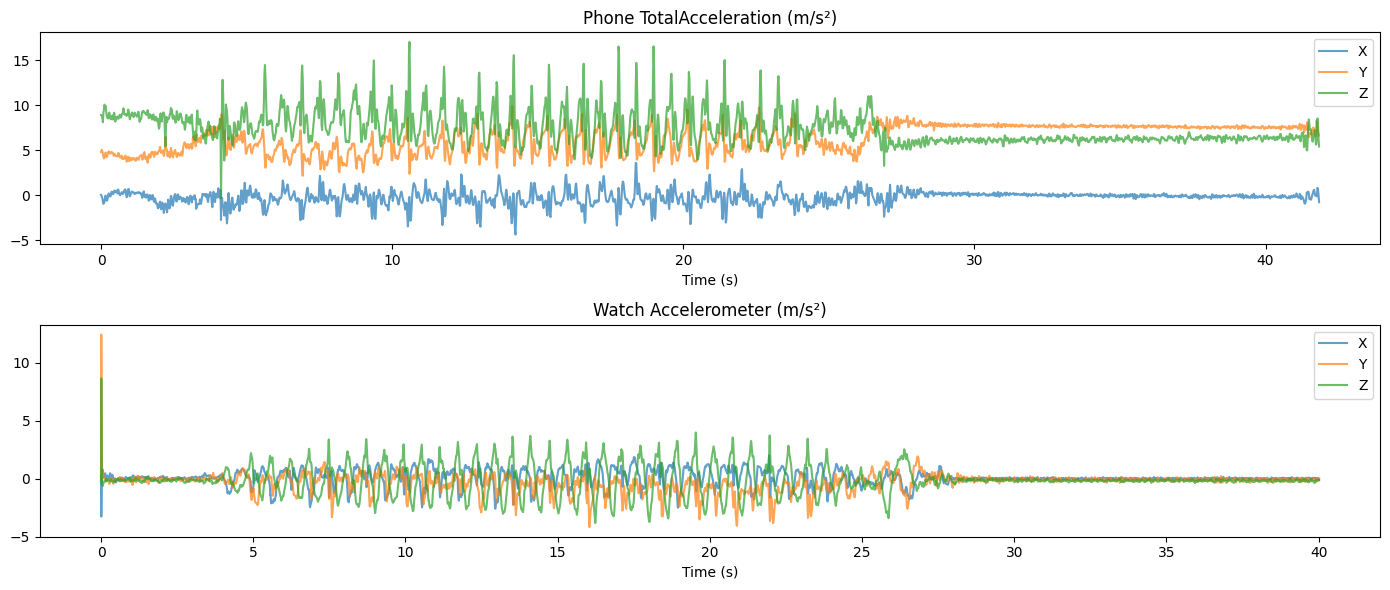

Phone actual rate: 53.9 Hz  (expected ~54 Hz)
Watch actual rate: 72.8 Hz  (expected ~73 Hz)


In [34]:
if not USE_SYNTHETIC:
    fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=False)

    axes[0].plot(t_phone_acc, phone_acc[:, 0], label='X', alpha=0.7)
    axes[0].plot(t_phone_acc, phone_acc[:, 1], label='Y', alpha=0.7)
    axes[0].plot(t_phone_acc, phone_acc[:, 2], label='Z', alpha=0.7)
    axes[0].set_title('Phone TotalAcceleration (m/s²)')
    axes[0].set_xlabel('Time (s)')
    axes[0].legend()

    axes[1].plot(t_watch_acc, watch_acc[:, 0], label='X', alpha=0.7)
    axes[1].plot(t_watch_acc, watch_acc[:, 1], label='Y', alpha=0.7)
    axes[1].plot(t_watch_acc, watch_acc[:, 2], label='Z', alpha=0.7)
    axes[1].set_title('Watch Accelerometer (m/s²)')
    axes[1].set_xlabel('Time (s)')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    # Estimate actual sample rates
    phone_hz = len(t_phone_acc) / (t_phone_acc[-1] - t_phone_acc[0])
    watch_hz = len(t_watch_acc) / (t_watch_acc[-1] - t_watch_acc[0])
    print(f"Phone actual rate: {phone_hz:.1f} Hz  (expected ~54 Hz)")
    print(f"Watch actual rate: {watch_hz:.1f} Hz  (expected ~73 Hz)")
else:
    print("[Synthetic mode] Skipping plot.")

## 5. Quaternion → 3×3 Rotation Matrix

MobilePoser's processed dataset stores orientation as 3×3 rotation matrices (`ori` field, shape `(frames, 6, 3, 3)`).  
Sensor Logger gives us quaternions, so we convert here using `scipy.spatial.transform.Rotation`.

In [35]:
def quat_to_rotmat(quats_wxyz):
    """
    Convert quaternions (N, 4) in [w, x, y, z] order to rotation matrices (N, 3, 3).
    scipy expects [x, y, z, w] so we reorder.
    """
    # Reorder from [w,x,y,z] to scipy's [x,y,z,w]
    quats_xyzw = quats_wxyz[:, [1, 2, 3, 0]]
    rot = R.from_quat(quats_xyzw)
    return rot.as_matrix().astype(np.float32)  # (N, 3, 3)


if not USE_SYNTHETIC:
    phone_rotmat = quat_to_rotmat(phone_quat)  # (N, 3, 3)
    watch_rotmat = quat_to_rotmat(watch_quat)  # (N, 3, 3)
    print(f"Phone rotation matrices: {phone_rotmat.shape}")
    print(f"Watch rotation matrices: {watch_rotmat.shape}")
    # Sanity check: det of a rotation matrix should be 1.0
    dets = np.linalg.det(phone_rotmat[:10])
    print(f"Determinant check (should be ~1.0): {dets.mean():.4f}")
else:
    print("[Synthetic mode] Skipping quaternion conversion.")

Phone rotation matrices: (2187, 3, 3)
Watch rotation matrices: (2858, 3, 3)
Determinant check (should be ~1.0): 1.0000


## 6. Resample to 30 Hz

MobilePoser was trained at **30 FPS** (`mobileposer/config.py → datasets.fps = 30`).
Our devices record at different rates, so we build a common 30 Hz time grid
covering the **overlap** of the two recordings, then interpolate all signals onto it.

In [36]:
def resample_signal(t_orig, signal, t_new):
    """
    Linearly interpolate signal (N, D) from t_orig onto t_new.
    Works for both acceleration (D=3) and flattened rotation matrices (D=9).
    """
    D = signal.shape[1]
    out = np.zeros((len(t_new), D), dtype=np.float32)
    for d in range(D):
        f = interp1d(t_orig, signal[:, d], kind='linear',
                     bounds_error=False, fill_value='extrapolate')
        out[:, d] = f(t_new)
    return out


def resample_rotmat(t_orig, rotmats, t_new):
    """Resample (N, 3, 3) rotation matrices by flattening to (N, 9), interpolating, reshaping back."""
    N_new = len(t_new)
    flat = rotmats.reshape(-1, 9)          # (N, 9)
    flat_resampled = resample_signal(t_orig, flat, t_new)  # (N_new, 9)
    return flat_resampled.reshape(N_new, 3, 3)


if not USE_SYNTHETIC:
    # Find the overlapping time window between phone and watch
    # Note: we use the *acceleration* timestamps as the reference for each device
    # and the orientation timestamps are close enough for our purposes.
    t_start = max(t_phone_acc[0], t_watch_acc[0],
                  t_phone_ori[0], t_watch_ori[0])
    t_end   = min(t_phone_acc[-1], t_watch_acc[-1],
                  t_phone_ori[-1], t_watch_ori[-1])

    duration = t_end - t_start
    n_frames = int(duration * TARGET_HZ)
    t_common = np.linspace(t_start, t_end, n_frames)  # common 60 Hz grid

    print(f"Overlap window : {t_start:.2f} → {t_end:.2f} s  ({duration:.1f} s)")
    print(f"Frames at {TARGET_HZ} Hz : {n_frames}  (~{duration:.0f} seconds of data)")

    phone_acc_60  = resample_signal(t_phone_acc, phone_acc,        t_common)  # (N, 3)
    watch_acc_60  = resample_signal(t_watch_acc, watch_acc,        t_common)  # (N, 3)
    phone_rot_60  = resample_rotmat(t_phone_ori, phone_rotmat,     t_common)  # (N, 3, 3)
    watch_rot_60  = resample_rotmat(t_watch_ori, watch_rotmat,     t_common)  # (N, 3, 3)

    print(f"\nResampled shapes:")
    print(f"  phone_acc_60 : {phone_acc_60.shape}")
    print(f"  watch_acc_60 : {watch_acc_60.shape}")
    print(f"  phone_rot_60 : {phone_rot_60.shape}")
    print(f"  watch_rot_60 : {watch_rot_60.shape}")

Overlap window : 0.00 → 40.01 s  (40.0 s)
Frames at 30 Hz : 1200  (~40 seconds of data)

Resampled shapes:
  phone_acc_60 : (1200, 3)
  watch_acc_60 : (1200, 3)
  phone_rot_60 : (1200, 3, 3)
  watch_rot_60 : (1200, 3, 3)


## 7. Synthetic Signal (fallback / unit test)

If `USE_SYNTHETIC = True`, we generate a fake 30-second walking signal.  
This lets you test the full pipeline end-to-end without a real recording.

In [37]:
if USE_SYNTHETIC:
    print(f"Generating synthetic walking signal (30 s at {TARGET_HZ} Hz)...")
    n_frames = 30 * TARGET_HZ  # 900 frames at 30 Hz
    t_common = np.linspace(0, 30, n_frames)

    # Gravity vector (device upright, gravity along -Z in sensor frame)
    gravity = np.array([0, 0, 9.81], dtype=np.float32)

    # Walking step frequency ~2 Hz; acceleration oscillates around gravity
    step_freq = 2.0
    step_phase = 2 * np.pi * step_freq * t_common

    def synthetic_walk_acc(phase_offset=0):
        acc = np.zeros((n_frames, 3), dtype=np.float32)
        acc[:, 0] = 0.5 * np.sin(step_phase + phase_offset)          # X: lateral sway
        acc[:, 1] = 1.0 * np.abs(np.sin(step_phase + phase_offset))  # Y: vertical bounce
        acc[:, 2] = 9.81 + 0.3 * np.cos(step_phase + phase_offset)   # Z: gravity + fore-aft
        acc += np.random.normal(0, 0.05, acc.shape)                   # small sensor noise
        return acc

    phone_acc_60 = synthetic_walk_acc(phase_offset=0)
    watch_acc_60 = synthetic_walk_acc(phase_offset=0.3)  # watch slightly out of phase

    # Identity rotation matrices (device held flat)
    phone_rot_60 = np.tile(np.eye(3, dtype=np.float32)[None], (n_frames, 1, 1))
    watch_rot_60 = np.tile(np.eye(3, dtype=np.float32)[None], (n_frames, 1, 1))

    print(f"Synthetic signal: {n_frames} frames")
    print(f"  phone_acc_60 : {phone_acc_60.shape}")
    print(f"  watch_acc_60 : {watch_acc_60.shape}")

    # Quick plot to verify
    plt.figure(figsize=(12, 3))
    plt.plot(t_common, phone_acc_60[:, 1], label='Phone Y (vertical)')
    plt.plot(t_common, watch_acc_60[:, 1], label='Watch Y (vertical)', alpha=0.7)
    plt.title('Synthetic walking acceleration')
    plt.xlabel('Time (s)')
    plt.legend()
    plt.show()

## 8. Build MobilePoser Input Tensors

MobilePoser's dataset stores IMU data for **6 body locations** (indices 0–5):

| Slot | Body location | Typical device |
|------|---------------|----------------|
| 0 | Left wrist | Watch |
| 1 | Right wrist | — |
| 2 | Left thigh | — |
| 3 | Right thigh | Phone in right pocket |
| 4 | Head | Headphones |
| 5 | Pelvis | — (dropped by model) |

The model only uses the **first 5** slots (0–4), configured via `amass.all_imu_ids = [0,1,2,3,4]`.

For the **`lw_rp`** combo (left-wrist + right-pocket), `amass.combos['lw_rp'] = [0, 3]`,
meaning we populate slots 0 (left wrist = watch) and 3 (right thigh = phone in pocket).

Acceleration is **divided by `acc_scale = 30`** before being fed to the model.

In [38]:
from mobileposer.config import amass, datasets, model_config
from mobileposer.utils.model_utils import smooth_avg

# ── Combo selection ────────────────────────────────────────────────────────
COMBO = 'lw_rp'
combo_slots = amass.combos[COMBO]   # [0, 3] → left_wrist, right_thigh
print(f"Combo '{COMBO}' uses dataset slots: {combo_slots}")

# ── Slot mapping ───────────────────────────────────────────────────────────
# Dataset slot order: 0=left_wrist, 1=right_wrist, 2=left_thigh,
#                     3=right_thigh, 4=head, 5=pelvis
# For lw_rp: watch → slot 0 (left_wrist), phone → slot 3 (right_thigh/pocket)
SLOT_LEFT_WRIST   = 0   # watch
SLOT_RIGHT_POCKET = 3   # phone

N = n_frames if USE_SYNTHETIC else len(t_common)

# ── Build full 6-slot acceleration tensor (N, 6, 3) ───────────────────────
acc_6 = np.zeros((N, 6, 3), dtype=np.float32)
acc_6[:, SLOT_LEFT_WRIST,   :] = watch_acc_60
acc_6[:, SLOT_RIGHT_POCKET, :] = phone_acc_60

# ── Build full 6-slot orientation tensor (N, 6, 3, 3) ─────────────────────
ori_6 = np.zeros((N, 6, 3, 3), dtype=np.float32)
for i in range(6):
    ori_6[:, i] = np.eye(3)
ori_6[:, SLOT_LEFT_WRIST,   :, :] = watch_rot_60
ori_6[:, SLOT_RIGHT_POCKET, :, :] = phone_rot_60

# ── Replicate MobilePoser's _get_imu() from loader.py ─────────────────────
acc_t = torch.from_numpy(acc_6)    # (N, 6, 3)
ori_t = torch.from_numpy(ori_6)    # (N, 6, 3, 3)

# 1. Zero out non-active slots, keep only combo slots
acc_masked = torch.zeros_like(acc_t)
ori_masked = torch.zeros_like(ori_t)
acc_masked[:, combo_slots] = acc_t[:, combo_slots]
ori_masked[:, combo_slots] = ori_t[:, combo_slots]

# 2. Select only the 5 model-used slots (drop pelvis at index 5)
acc_5 = acc_masked[:, amass.all_imu_ids]   # (N, 5, 3)
ori_5 = ori_masked[:, amass.all_imu_ids]   # (N, 5, 3, 3)

# 3. Scale acceleration
acc_5 = acc_5 / amass.acc_scale

# 4. Apply smoothing (same as training pipeline)
acc_5 = smooth_avg(acc_5)

# 5. Flatten and concatenate → (N, 60)
imu_input = torch.cat([acc_5.flatten(1), ori_5.flatten(1)], dim=1)  # (N, 15+45) = (N, 60)

# 6. Add batch dimension → (1, N, 60)
batch_t = imu_input.float().unsqueeze(0)

print(f"\nInput tensor shape: {tuple(batch_t.shape)}")
print(f"  Expected: (1, {N}, {model_config.n_imu})")
print(f"  acc_scale applied: /{amass.acc_scale}")
print(f"  Active combo slots: {combo_slots}")

# Also keep the raw tensors for saving later
acc_tensor = acc_6
ori_tensor = ori_6

Combo 'lw_rp' uses dataset slots: [0, 3]

Input tensor shape: (1, 1200, 60)
  Expected: (1, 1200, 60)
  acc_scale applied: /30
  Active combo slots: [0, 3]


## 9. Load MobilePoser and Run Inference

We load the pre-trained model and run `forward_offline()` which:
1. Predicts joint positions from IMU data
2. Predicts body pose (SMPL rotations)
3. Estimates root velocity and foot-ground contact
4. Integrates velocity into translation (with floor-penetration removal)

In [39]:
from mobileposer.models import MobilePoserNet

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Load model
model = MobilePoserNet().to(device)
state = torch.load(WEIGHTS_FILE, map_location=device)
model.load_state_dict(state)
model.eval()
print("Model loaded OK")

# Run forward_offline — this does everything: pose, joints, translation
with torch.no_grad():
    pred_pose, pred_joints, pred_tran, pred_contact = model.forward_offline(
        batch_t.to(device)
    )

# Move outputs to CPU
pred_pose    = pred_pose.cpu()       # (N, 24, 3, 3) local rotation matrices
pred_joints  = pred_joints.squeeze(0).cpu()  # (N, 24, 3) joint positions
pred_tran    = pred_tran.cpu()       # (N, 3) root translation
pred_contact = pred_contact.cpu()    # (N, 2) foot contact probabilities

tran_np = pred_tran.numpy()

print("\nInference complete:")
print(f"  pred_pose    : {tuple(pred_pose.shape)}")
print(f"  pred_joints  : {tuple(pred_joints.shape)}")
print(f"  pred_tran    : {tuple(pred_tran.shape)}")
print(f"  pred_contact : {tuple(pred_contact.shape)}")
print(f"\nFinal position: x={tran_np[-1,0]:.3f}  y={tran_np[-1,1]:.3f}  z={tran_np[-1,2]:.3f} m")

Using device: cpu
Model loaded OK

Inference complete:
  pred_pose    : (1200, 24, 3, 3)
  pred_joints  : (1200, 72)
  pred_tran    : (1200, 3)
  pred_contact : (1200, 2)

Final position: x=1.215  y=-0.247  z=2.202 m


## 10b. Option B — Export for Unity3D

MobilePoser includes `save_unity_motion()` which writes `pose.txt` and `tran.txt`.  
You can load these in the Unity demo scene that comes with MobilePoser, or in any
Unity project using their `LoadMotion()` script.

This is the **best option if you want to share or inspect the animation in a game engine**.

In [41]:
# ══════════════════════════════════════════════════════════════════════════
# OPTION B — Export pose.txt + tran.txt for Unity3D
# ══════════════════════════════════════════════════════════════════════════

import mobileposer.articulate as art
from mobileposer.config import paths

UNITY_OUTPUT_DIR = os.path.join(
    RECORDING_DIR if not USE_SYNTHETIC else '.', 'unity_motion'
)

bodymodel = art.model.ParametricModel(paths.smpl_file, device='cpu')
bodymodel.save_unity_motion(
    pose=pred_pose,       # (N, 24, 3, 3) rotation matrices
    tran=pred_tran,       # (N, 3) root translation
    output_dir=UNITY_OUTPUT_DIR
)

print(f"Unity motion files saved to: {UNITY_OUTPUT_DIR}/")
print(f"  pose.txt  — {pred_pose.shape[0]} frames, 72 axis-angle values per line")
print(f"  tran.txt  — {pred_tran.shape[0]} frames, 3 values (x,y,z) per line")
print()
print("To use in Unity:")
print("  1. Copy pose.txt and tran.txt into your Unity project's StreamingAssets/")
print("  2. Use MobilePoser's LoadMotion() script to animate an SMPL avatar")

Unity motion files saved to: ./data/sensor/default\unity_motion/
  pose.txt  — 1200 frames, 72 axis-angle values per line
  tran.txt  — 1200 frames, 3 values (x,y,z) per line

To use in Unity:
  1. Copy pose.txt and tran.txt into your Unity project's StreamingAssets/
  2. Use MobilePoser's LoadMotion() script to animate an SMPL avatar


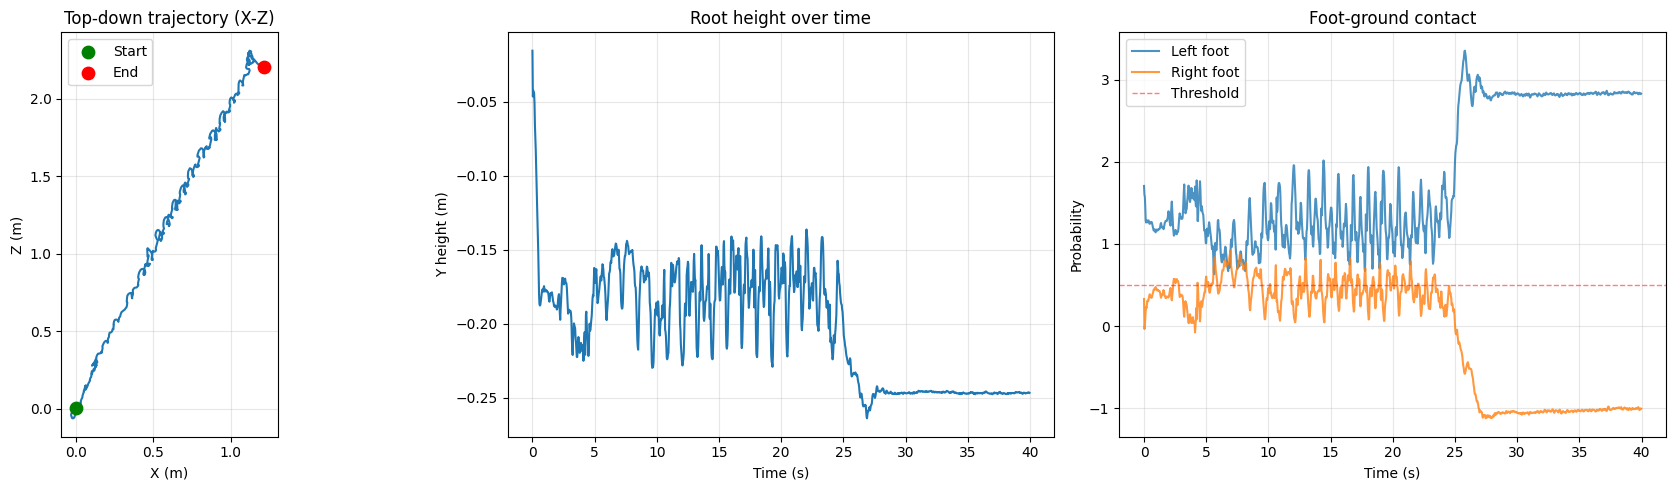

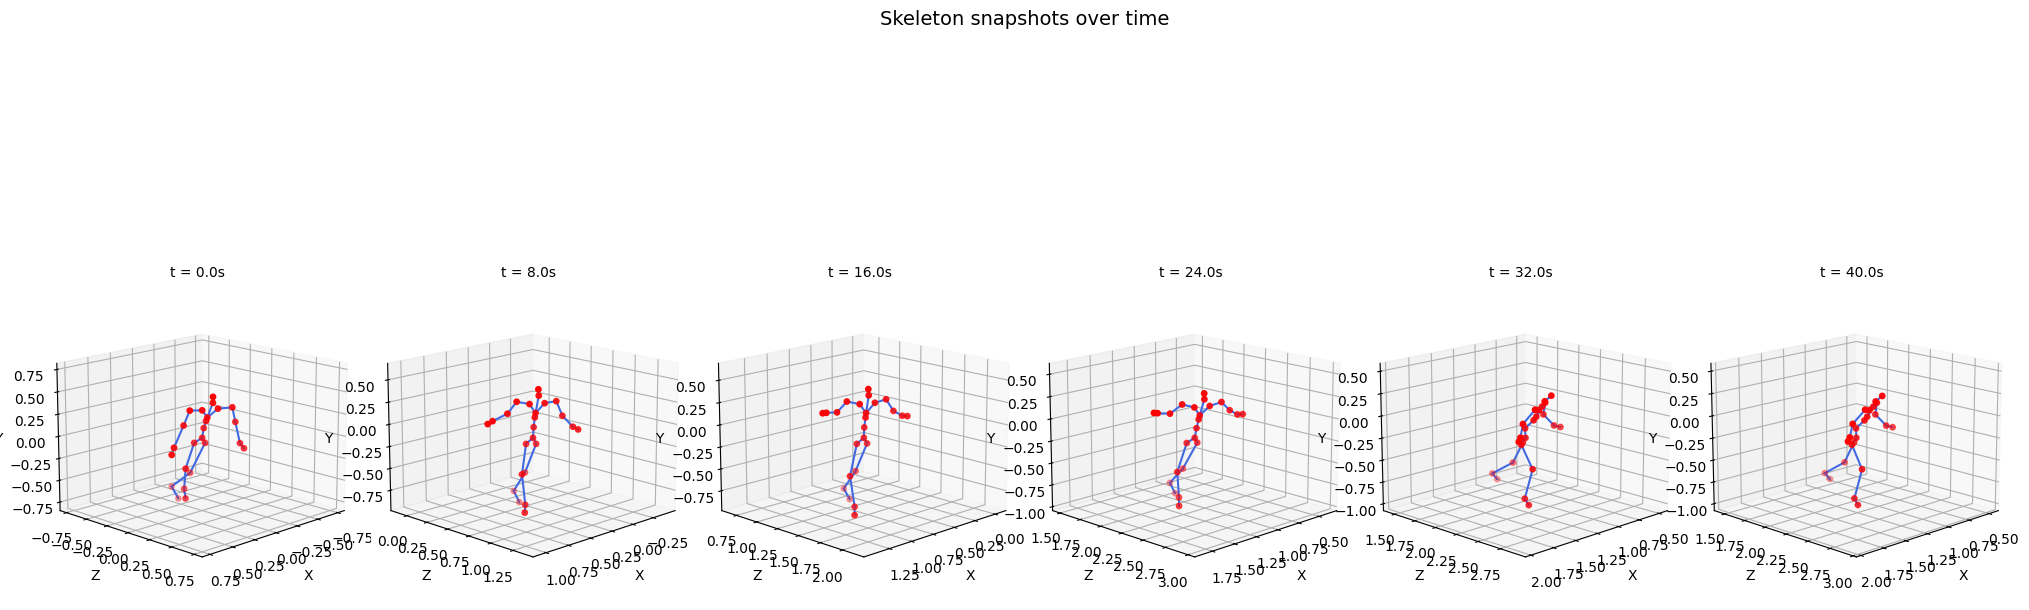


--- Sanity Check ---
Duration         : 40.0 s  (1200 frames at 30 Hz)
Total distance   : 6.20 m  (horizontal X-Z plane)
Avg speed        : 0.16 m/s  (normal walking ~ 1.2-1.5 m/s)
Height range     : -0.264 to -0.016 m
Foot contact %   : L=100%  R=23%
Final position   : x=1.22  y=-0.25  z=2.20 m


In [42]:
# ══════════════════════════════════════════════════════════════════════════
# OPTION C — Matplotlib sanity-check plots
# ══════════════════════════════════════════════════════════════════════════
#
# These are quick diagnostic plots — not meant to replace the SMPL viewer,
# but useful for verifying the output makes sense before doing a full render.

joint_np = pred_joints.view(-1, 24, 3).numpy()   # (N, 24, 3)
tran_np  = pred_tran.numpy()                      # (N, 3)
contact_np = pred_contact.numpy()                 # (N, 2)
t_axis = np.arange(len(tran_np)) / TARGET_HZ

# ── Plot 1: Trajectory (top-down + height) ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Top-down view (X-Z)
axes[0].plot(tran_np[:, 0], tran_np[:, 2], linewidth=1.5)
axes[0].scatter(tran_np[0, 0], tran_np[0, 2], color='green', s=80, label='Start', zorder=5)
axes[0].scatter(tran_np[-1, 0], tran_np[-1, 2], color='red', s=80, label='End', zorder=5)
axes[0].set_xlabel('X (m)'); axes[0].set_ylabel('Z (m)')
axes[0].set_title('Top-down trajectory (X-Z)')
axes[0].legend(); axes[0].set_aspect('equal'); axes[0].grid(True, alpha=0.3)

# Height over time
axes[1].plot(t_axis, tran_np[:, 1])
axes[1].set_xlabel('Time (s)'); axes[1].set_ylabel('Y height (m)')
axes[1].set_title('Root height over time')
axes[1].grid(True, alpha=0.3)

# Foot contact over time
axes[2].plot(t_axis, contact_np[:, 0], label='Left foot', alpha=0.8)
axes[2].plot(t_axis, contact_np[:, 1], label='Right foot', alpha=0.8)
axes[2].axhline(0.5, color='red', ls='--', lw=1, alpha=0.5, label='Threshold')
axes[2].set_xlabel('Time (s)'); axes[2].set_ylabel('Probability')
axes[2].set_title('Foot-ground contact')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── Plot 2: Skeleton snapshots at key frames ──────────────────────────────
SMPL_BONES = [
    (0,1),(0,2),(0,3),(1,4),(2,5),(3,6),(4,7),(5,8),(6,9),
    (7,10),(8,11),(9,12),(9,13),(9,14),(12,15),(13,16),(14,17),
    (16,18),(17,19),(18,20),(19,21),(20,22),(21,23),
]

# Pick 6 evenly-spaced frames
n_snapshots = 6
snapshot_idxs = np.linspace(0, len(joint_np)-1, n_snapshots, dtype=int)

fig = plt.figure(figsize=(20, 8))
for i, idx in enumerate(snapshot_idxs):
    ax = fig.add_subplot(1, n_snapshots, i+1, projection='3d')
    J = joint_np[idx] + tran_np[idx]  # global joint positions
    
    ax.scatter(J[:, 0], J[:, 2], J[:, 1], c='red', s=15, depthshade=True)
    for p, c in SMPL_BONES:
        ax.plot([J[p,0], J[c,0]], [J[p,2], J[c,2]], [J[p,1], J[c,1]], 
                c='royalblue', lw=1.5)
    
    ax.set_title(f't = {idx/TARGET_HZ:.1f}s', fontsize=10)
    # Set consistent limits centered on root
    r = 0.8
    ctr = J[0]
    ax.set_xlim(ctr[0]-r, ctr[0]+r)
    ax.set_ylim(ctr[2]-r, ctr[2]+r)
    ax.set_zlim(ctr[1]-r, ctr[1]+r)
    ax.set_xlabel('X'); ax.set_ylabel('Z'); ax.set_zlabel('Y')
    ax.view_init(elev=15, azim=45)

fig.suptitle('Skeleton snapshots over time', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ── Sanity-check summary ──────────────────────────────────────────────────
total_dist = np.sqrt(np.sum(np.diff(tran_np[:, [0,2]], axis=0)**2, axis=1)).sum()
duration = len(tran_np) / TARGET_HZ
print(f"\n--- Sanity Check ---")
print(f"Duration         : {duration:.1f} s  ({len(tran_np)} frames at {TARGET_HZ} Hz)")
print(f"Total distance   : {total_dist:.2f} m  (horizontal X-Z plane)")
print(f"Avg speed        : {total_dist/duration:.2f} m/s  (normal walking ~ 1.2-1.5 m/s)")
print(f"Height range     : {tran_np[:,1].min():.3f} to {tran_np[:,1].max():.3f} m")
print(f"Foot contact %   : L={100*( contact_np[:,0]>0.5).mean():.0f}%  R={100*(contact_np[:,1]>0.5).mean():.0f}%")
print(f"Final position   : x={tran_np[-1,0]:.2f}  y={tran_np[-1,1]:.2f}  z={tran_np[-1,2]:.2f} m")

## 11. Save Processed Data for Later Steps

Save the resampled input tensors and model output so downstream steps  
(e.g. Kalman filter dead reckoning) can load them without re-running the pipeline.

Everything is also available as Unity-ready files in the `unity_motion/` folder (from Option B above).

In [43]:
import os

OUTPUT_DIR = os.path.join(RECORDING_DIR, 'processed') if not USE_SYNTHETIC else 'processed_synthetic'
os.makedirs(OUTPUT_DIR, exist_ok=True)

save_dict = {
    'acc'          : acc_tensor,                   # (N, 6, 3) — resampled input
    'ori'          : ori_tensor,                   # (N, 6, 3, 3)
    'tran'         : tran_np,                      # (N, 3) — integrated translation
    'joints'       : pred_joints.view(-1, 24, 3).numpy(),  # (N, 24, 3)
    'pose'         : pred_pose.numpy(),            # (N, 24, 3, 3) — joint rotations
    'contact'      : pred_contact.numpy(),         # (N, 2) — foot contact probabilities
    'target_hz'    : TARGET_HZ,
    'combo'        : COMBO,
    'mode'         : RECORDING_MODE,
    'synthetic'    : USE_SYNTHETIC,
}

out_path = os.path.join(OUTPUT_DIR, 'step0_output.npz')
np.savez(out_path, **save_dict)
print(f"Saved to: {out_path}")
print("Keys:", list(save_dict.keys()))

Saved to: ./data/sensor/default\processed\step0_output.npz
Keys: ['acc', 'ori', 'tran', 'joints', 'pose', 'contact', 'target_hz', 'combo', 'mode', 'synthetic']
